In [1]:
import os
import re
from typing import Literal, Any
from typing_extensions import TypedDict, Annotated

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

load_dotenv()

OPENAI_MODEL = os.getenv("LLM_MODEL", "gpt-4o-mini")
OPENAI_TEMPERATURE = float(os.getenv("LLM_TEMPERATURE", "0.2"))


def get_llm() -> ChatOpenAI:
    return ChatOpenAI(model=OPENAI_MODEL, temperature=OPENAI_TEMPERATURE)


class SmartMoveState(TypedDict):
    messages: Annotated[list[Any], add_messages]

    user_query: str
    intent: str | None

    origin: str | None
    destination: str | None
    departure_time: str | None
    date: str | None
    transport_type: str | None

    missing_fields: list[str] | None

    cypher_query: str | None
    result: str | None
    response: str | None
    follow_up_question: str | None

In [2]:
def normalize_datetime(raw_text: str) -> str | None:
    """Normalize simple date/time expressions into compact text."""
    if not raw_text:
        return None

    # Relative time like "after 10 am" / "before 6:30 pm"
    rel = re.search(r"\b(after|before)\s+(\d{1,2}(?::\d{2})?\s*(?:am|pm))\b", raw_text, re.IGNORECASE)
    if rel:
        return f"{rel.group(1).lower()} {rel.group(2).lower()}"

    # Date with optional time, e.g. "8 August 2024 at 8 PM"
    m = re.search(r"(\d{1,2}\s+[A-Za-z]+\s+\d{4}(?:\s+at\s+\d{1,2}(?::\d{2})?\s*(?:AM|PM|am|pm)?)?)", raw_text)
    if m:
        return m.group(1)

    # ISO-ish date/time
    m2 = re.search(r"(\d{4}-\d{2}-\d{2}(?:\s+\d{2}:\d{2})?)", raw_text)
    if m2:
        return m2.group(1)

    # Standalone time, e.g. "at 8 pm"
    t = re.search(r"\bat\s+(\d{1,2}(?::\d{2})?\s*(?:am|pm))\b", raw_text, re.IGNORECASE)
    if t:
        return t.group(1).lower()

    return None


def _clean_place(value: str | None) -> str | None:
    if not value:
        return None
    cleaned = value.strip().lower()
    cleaned = re.sub(r"^(?:the\s+)?city\s+of\s+", "", cleaned, flags=re.IGNORECASE)
    # Remove accidental verb prefixes captured by loose regexes.
    while True:
        next_cleaned = re.sub(r"^(?:need\s+to\s+|go\s+to\s+|go\s+|travel\s+to\s+|travel\s+|reach\s+|get\s+to\s+|get\s+)", "", cleaned, flags=re.IGNORECASE)
        if next_cleaned == cleaned:
            break
        cleaned = next_cleaned
    return cleaned.strip() or None


def extract_transport_fields(user_query: str) -> dict[str, str | None]:
    text = user_query or ""

    transport_type = None
    for t in ["bus", "train", "car", "taxi", "metro", "flight", "ferry"]:
        if re.search(rf"\b{t}\b", text, re.IGNORECASE):
            transport_type = t
            break

    origin = None
    destination = None

    # "go kandy from colombo ..." / "go to kandy from colombo ..."
    go_from = re.search(
        r"(?:go(?:\s+to)?|travel(?:\s+to)?|reach|get(?:\s+to)?)\s+([A-Za-z\s]+?)\s+from\s+([A-Za-z\s]+?)(?:$|\s+(?:on|at|by|for|after|before)\b)",
        text,
        re.IGNORECASE,
    )
    if go_from:
        destination = go_from.group(1).strip()
        origin = go_from.group(2).strip()

    # "from colombo to kandy ..."
    if not (origin and destination):
        from_to = re.search(
            r"from\s+([A-Za-z\s]+?)\s+to\s+([A-Za-z\s]+?)(?:$|\s+(?:on|at|by|for|after|before)\b)",
            text,
            re.IGNORECASE,
        )
        if from_to:
            origin = from_to.group(1).strip()
            destination = from_to.group(2).strip()

    # "to kandy from colombo ..."
    if not (origin and destination):
        to_from = re.search(
            r"\bto\s+([A-Za-z\s]+?)\s+from\s+([A-Za-z\s]+?)(?:$|\s+(?:on|at|by|for|after|before)\b)",
            text,
            re.IGNORECASE,
        )
        if to_from:
            destination = to_from.group(1).strip()
            origin = to_from.group(2).strip()

    # "go to kandy"
    if not destination:
        to_match = re.search(r"(?:go|travel|reach|get)\s+to\s+([A-Za-z\s]+?)(?:$|\s+(?:on|at|by|for|after|before)\b)", text, re.IGNORECASE)
        if to_match:
            destination = to_match.group(1).strip()

    # "go kandy"
    if not destination:
        go_match = re.search(r"(?:go|get|travel|reach)\s+([A-Za-z\s]+?)(?:$|\s+(?:on|at|by|for|after|before)\b)", text, re.IGNORECASE)
        if go_match:
            destination = go_match.group(1).strip()

    origin = _clean_place(origin)
    destination = _clean_place(destination)
    departure_time = normalize_datetime(text)

    return {
        "origin": origin,
        "destination": destination,
        "departure_time": departure_time,
        "date": departure_time,
        "transport_type": transport_type,
    }


def validate_mandatory_fields(state: SmartMoveState) -> list[str]:
    missing = []
    if not state.get("origin"):
        missing.append("origin")
    if not state.get("destination"):
        missing.append("destination")
    if not state.get("departure_time"):
        missing.append("departure_time")
    return missing


def generate_cypher_for_transport(state: SmartMoveState) -> str:
    # In notebook demo, generate a deterministic query template.
    transport = state.get("transport_type") or "any"
    origin = state.get("origin") or "<origin>"
    destination = state.get("destination") or "<destination>"
    departure = state.get("departure_time") or "<departure_time>"

    return (
        "MATCH (o:Location {name: $origin})-[:CONNECTS]->(r:Route)-[:CONNECTS]->(d:Location {name: $destination}) "
        "WHERE ($transport = 'any' OR r.transport_type = $transport) "
        "RETURN o.name AS origin, d.name AS destination, r.transport_type AS transport_type, "
        "$departure AS departure_time, r.duration AS duration, r.price AS price"
    ).replace("$origin", f"'{origin}'").replace("$destination", f"'{destination}'").replace("$transport", f"'{transport}'").replace("$departure", f"'{departure}'")


def execute_neo4j_safe(cypher_query: str) -> str:
    """Notebook-safe result mock; replace with real Neo4j driver when needed."""
    return (
        "MockResult: 2 routes found | "
        "[{'origin': 'Colombo', 'destination': 'Kandy', 'transport_type': 'bus', 'duration': '3h', 'price': 'LKR 1200'}, "
        "{'origin': 'Colombo', 'destination': 'Kandy', 'transport_type': 'train', 'duration': '2h 30m', 'price': 'LKR 1500'}]"
    )


In [3]:
def intent_detection_node(state: SmartMoveState) -> SmartMoveState:
    query = state.get("user_query") or ""

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are SmartMove intent router.
Classify user message into one of: greeting, transport, fallback.
Return only one label."""),
        ("human", "{query}"),
    ])

    intent = (prompt | get_llm()).invoke({"query": query}).content.strip().lower()
    if intent not in {"greeting", "transport", "fallback"}:
        intent = "fallback"

    return {**state, "intent": intent}


def greeting_node(state: SmartMoveState) -> SmartMoveState:
    response = "Welcome to SmartMove. I can help with routes, schedules, and transport options."
    return {
        **state,
        "response": response,
        "messages": state.get("messages", []) + [AIMessage(content=response)],
    }


def fallback_node(state: SmartMoveState) -> SmartMoveState:
    response = "SmartMove supports transportation queries only. Please ask about routes, stations, or travel options."
    return {
        **state,
        "response": response,
        "messages": state.get("messages", []) + [AIMessage(content=response)],
    }


def query_understanding_node(state: SmartMoveState) -> SmartMoveState:
    """Extract fields and preserve already collected mandatory values in state."""
    extracted = extract_transport_fields(state.get("user_query") or "")

    merged = {
        "origin": state.get("origin") or extracted.get("origin"),
        "destination": state.get("destination") or extracted.get("destination"),
        "departure_time": state.get("departure_time") or extracted.get("departure_time"),
        "date": state.get("date") or extracted.get("date"),
        "transport_type": state.get("transport_type") or extracted.get("transport_type"),
    }

    return {**state, **merged}


def missing_info_validator_node(state: SmartMoveState) -> SmartMoveState:
    missing = validate_mandatory_fields(state)
    return {**state, "missing_fields": missing}


def _extract_missing_field_updates(state: SmartMoveState, missing: list[str], user_text: str) -> dict[str, str | None]:
    """Extract only the fields we asked for from follow-up user input."""
    extracted = extract_transport_fields(user_text)
    updates: dict[str, str | None] = {}

    for field in missing:
        current_value = state.get(field)
        if current_value:
            continue

        value = extracted.get(field)

        # Fallbacks for short answers such as "Colombo" or "8 PM".
        if not value:
            if field in {"origin", "destination"}:
                value = _clean_place(user_text)
            elif field == "departure_time":
                value = normalize_datetime(user_text) or user_text.strip().lower() or None

        if value:
            updates[field] = value

    return updates


def follow_up_question_node(state: SmartMoveState) -> SmartMoveState:
    missing = state.get("missing_fields") or []

    field_map = {
        "origin": "origin",
        "destination": "destination",
        "departure_time": "departure time",
    }
    missing_text = ", ".join(field_map.get(f, f) for f in missing)
    response = f"Please provide the following required details: {missing_text}."

    human_reply = interrupt(
        {
            "kind": "follow_up_question",
            "question": response,
            "missing_fields": missing,
        }
    )

    human_text = str(human_reply).strip()
    updates = _extract_missing_field_updates(state, missing, human_text)

    return {
        **state,
        **updates,
        "follow_up_question": response,
        "response": response,
        "messages": state.get("messages", []) + [AIMessage(content=response), HumanMessage(content=human_text)],
    }


def user_reply_node(state: SmartMoveState) -> SmartMoveState:
    """Unused in interrupt flow, kept for compatibility."""
    return state


def cypher_generator_node(state: SmartMoveState) -> SmartMoveState:
    cypher = generate_cypher_for_transport(state)
    return {**state, "cypher_query": cypher}


def neo4j_query_node(state: SmartMoveState) -> SmartMoveState:
    result = execute_neo4j_safe(state.get("cypher_query") or "")
    return {**state, "result": result}


def response_formatter_node(state: SmartMoveState) -> SmartMoveState:
    query = state.get("user_query") or ""
    result = state.get("result") or "No result"

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are SmartMove response formatter.
Create a concise transportation-focused answer from the result.
No filler text."""),
        ("human", "Query: {query}\nResult: {result}"),
    ])

    response = (prompt | get_llm()).invoke({"query": query, "result": result}).content
    return {
        **state,
        "response": response,
        "messages": state.get("messages", []) + [AIMessage(content=response)],
    }


def route_intent(state: SmartMoveState) -> Literal["greeting", "transport", "fallback"]:
    return state.get("intent") or "fallback"


def route_missing_info(state: SmartMoveState) -> Literal["follow_up", "continue"]:
    return "follow_up" if (state.get("missing_fields") or []) else "continue"


In [4]:
graph = StateGraph(SmartMoveState)

# Core nodes
graph.add_node("intent_detection", intent_detection_node)
graph.add_node("greeting", greeting_node)
graph.add_node("fallback", fallback_node)

# Transport sub-flow
graph.add_node("query_understanding", query_understanding_node)
graph.add_node("missing_info_validator", missing_info_validator_node)
graph.add_node("follow_up_question", follow_up_question_node)
graph.add_node("cypher_generator", cypher_generator_node)
graph.add_node("neo4j_query", neo4j_query_node)
graph.add_node("response_formatter", response_formatter_node)

graph.add_edge(START, "intent_detection")

graph.add_conditional_edges(
    "intent_detection",
    route_intent,
    {
        "greeting": "greeting",
        "transport": "query_understanding",
        "fallback": "fallback",
    },
)

graph.add_edge("greeting", END)
graph.add_edge("fallback", END)

graph.add_edge("query_understanding", "missing_info_validator")
graph.add_conditional_edges(
    "missing_info_validator",
    route_missing_info,
    {
        "follow_up": "follow_up_question",
        "continue": "cypher_generator",
    },
)

# Human-in-the-loop behavior: resume with user input, then validate again.
graph.add_edge("follow_up_question", "missing_info_validator")

graph.add_edge("cypher_generator", "neo4j_query")
graph.add_edge("neo4j_query", "response_formatter")
graph.add_edge("response_formatter", END)

memory = MemorySaver()
app = graph.compile(checkpointer=memory)

app.get_graph()


Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'intent_detection': Node(id='intent_detection', name='intent_detection', data=intent_detection(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'greeting': Node(id='greeting', name='greeting', data=greeting(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'fallback': Node(id='fallback', name='fallback', data=fallback(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'query_understanding': Node(id='query_understanding', name='query_understanding', data=query_understanding(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'missing_info_validator': Node(id='missing_info_validator', name='missing_info_validator', data=missing_info_validator(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata

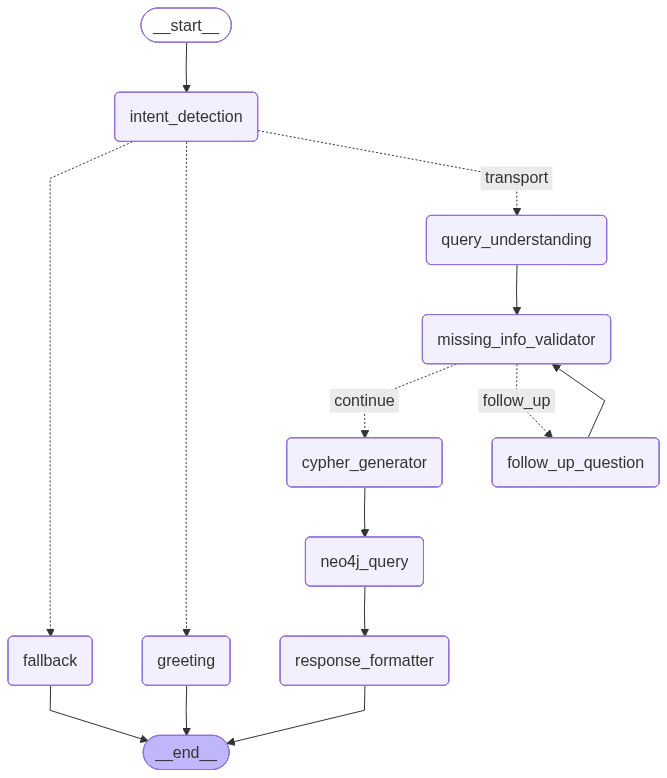

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [11]:
def run_case(user_text: str, thread_id: str = "demo-thread", follow_up_reply: str | None = None):
    cfg = {"configurable": {"thread_id": thread_id}}

    state: SmartMoveState = {
        "messages": [HumanMessage(content=user_text)],
        "user_query": user_text,
        "intent": None,
        "origin": None,
        "destination": None,
        "departure_time": None,
        "date": None,
        "transport_type": None,
        "missing_fields": None,
        "cypher_query": None,
        "result": None,
        "response": None,
        "follow_up_question": None,
    }

    out = app.invoke(state, cfg)

    # If graph interrupted for human input, resume with provided reply.
    if "__interrupt__" in out:
        payload = out["__interrupt__"][0].value
        print("\n=== SmartMove Follow-up ===")
        print(payload.get("question"))

        if not follow_up_reply:
            print("\n[Waiting for human input] Re-run with follow_up_reply='...'")
            return out

        out = app.invoke(Command(resume=follow_up_reply), cfg)

    print("\n=== User ===")
    print(user_text)
    if follow_up_reply:
        print("\n=== Human Follow-up Input ===")
        print(follow_up_reply)

    print("\n=== SmartMove Reply ===")
    print(out.get("response"))
    print("\n=== State ===")
    print({
        "intent": out.get("intent"),
        "origin": out.get("origin"),
        "destination": out.get("destination"),
        "departure_time": out.get("departure_time"),
        "transport_type": out.get("transport_type"),
        "missing_fields": out.get("missing_fields"),
        "cypher_query": out.get("cypher_query"),
        "result": out.get("result"),
    })
    return out


# 1) Greeting case
# _ = run_case("Hi SmartMove", thread_id="case-1")

# # 2) Incomplete transport query -> follow-up interrupt -> resume with human input
# _ = run_case("Bus to Kandy", thread_id="case-2", follow_up_reply="from Colombo after 8 PM")
_ = run_case("i want to plan a trip", thread_id="case-2", follow_up_reply="from Colombo after 8 PM")


# # 3) Complete transport query (continues without interrupt)
# _ = run_case("Find bus from Colombo to Kandy after 8 PM", thread_id="case-3")



=== SmartMove Follow-up ===
Please provide the following required details: origin, destination, departure time.

=== User ===
i want to plan a trip

=== Human Follow-up Input ===
from Colombo after 8 PM

=== SmartMove Reply ===
Two transportation options from Colombo to Kandy:

1. **Bus**: 
   - Duration: 3 hours
   - Price: LKR 1200

2. **Train**: 
   - Duration: 2 hours 30 minutes
   - Price: LKR 1500

=== State ===
{'intent': 'transport', 'origin': 'from colombo after 8 pm', 'destination': 'from colombo after 8 pm', 'departure_time': 'after 8 pm', 'transport_type': None, 'missing_fields': [], 'cypher_query': "MATCH (o:Location {name: 'from colombo after 8 pm'})-[:CONNECTS]->(r:Route)-[:CONNECTS]->(d:Location {name: 'from colombo after 8 pm'}) WHERE ('any' = 'any' OR r.transport_type = 'any') RETURN o.name AS origin, d.name AS destination, r.transport_type AS transport_type, 'after 8 pm' AS departure_time, r.duration AS duration, r.price AS price", 'result': "MockResult: 2 routes fo

## Expected Behavior (SmartMove)

- SmartMove handles **transportation-only** requests.
- Mandatory fields for transport flow:
  - `origin`
  - `destination`
  - `departure_time`
- If any mandatory field is missing, graph raises a human-in-the-loop interrupt from `follow_up_question`.
- User follow-up input is resumed with `Command(resume=...)`, parsed, and merged into state.
- Flow loops through validation until mandatory fields are complete, then proceeds:
  - Cypher generation
  - Neo4j execution (mock in this notebook)
  - Final response formatting

### Switch From Mock To Real Neo4j

Replace `execute_neo4j_safe(...)` with a real Neo4j driver call (same pattern as `smartmove/tools.py`) and keep the same return shape for smooth integration.


In [8]:
_ = run_case("i need to plan a trip")


=== User ===
i need to plan a trip

=== SmartMove Reply ===
Please provide the following required details: origin, destination, departure time.

=== State ===
{'intent': 'transport', 'origin': None, 'destination': None, 'departure_time': None, 'transport_type': None, 'missing_fields': ['origin', 'destination', 'departure_time'], 'cypher_query': None, 'result': None}


In [9]:
_ = run_case("i need to go to kandy from colombo")


=== User ===
i need to go to kandy from colombo

=== SmartMove Reply ===
Please provide the following required details: departure time.

=== State ===
{'intent': 'transport', 'origin': 'colombo', 'destination': 'kandy', 'departure_time': None, 'transport_type': None, 'missing_fields': ['departure_time'], 'cypher_query': None, 'result': None}


In [10]:
_ = run_case("i need to go kandy from colombo after 10 am")


=== User ===
i need to go kandy from colombo after 10 am

=== SmartMove Reply ===
You have two transportation options from Colombo to Kandy after 10 AM:

1. **Bus**: Duration - 3 hours, Price - LKR 1200
2. **Train**: Duration - 2 hours 30 minutes, Price - LKR 1500

=== State ===
{'intent': 'transport', 'origin': 'colombo', 'destination': 'kandy', 'departure_time': 'after 10 am', 'transport_type': None, 'missing_fields': [], 'cypher_query': "MATCH (o:Location {name: 'colombo'})-[:CONNECTS]->(r:Route)-[:CONNECTS]->(d:Location {name: 'kandy'}) WHERE ('any' = 'any' OR r.transport_type = 'any') RETURN o.name AS origin, d.name AS destination, r.transport_type AS transport_type, 'after 10 am' AS departure_time, r.duration AS duration, r.price AS price", 'result': "MockResult: 2 routes found | [{'origin': 'Colombo', 'destination': 'Kandy', 'transport_type': 'bus', 'duration': '3h', 'price': 'LKR 1200'}, {'origin': 'Colombo', 'destination': 'Kandy', 'transport_type': 'train', 'duration': '2h 3

In [11]:
_ = run_case("i need to go colombo")



=== User ===
i need to go colombo

=== SmartMove Reply ===
Please provide the following required details: origin, departure time.

=== State ===
{'intent': 'transport', 'origin': None, 'destination': 'colombo', 'departure_time': None, 'transport_type': None, 'missing_fields': ['origin', 'departure_time'], 'cypher_query': None, 'result': None}


In [ ]:
_ = run_case("i need to plan a trip")


In [ ]:
_ = run_case("bus to kandy from colombo")

In [ ]:
_ = run_case("after 8pm")

In [12]:
_ = run_case("after 8pm")


=== User ===
after 8pm

=== SmartMove Reply ===
Please provide the following required details: origin, destination.

=== State ===
{'intent': 'transport', 'origin': None, 'destination': None, 'departure_time': 'after 8pm', 'transport_type': None, 'missing_fields': ['origin', 'destination'], 'cypher_query': None, 'result': None}
